<a href="https://colab.research.google.com/github/wnstj1126-debug/-/blob/main/OnlineSim_FEMTO_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 온라인 시뮬레이션 v3 — BW=420 재검증 + 적응형 등록 종료

**v2 → v3 수정 내용:**
- `AssertionError: 파일 없음` 오류 수정
- FEMTO 폴더명은 배포본마다 다름 (`Learning_set`, `Training_set`, `learning_set` 등)
- **S0에서 드라이브 마운트 직후 실제 폴더를 자동 탐색 → 경로 자동 확정**
- 이후 모든 셀은 자동 확정된 경로를 사용하므로 수동 수정 불필요

**실행 순서:** `A` → **런타임재시작** → `A-2` → `S0(경로자동확정)` → `S3-420` → `S3-ADAPT` → `CMP` → `TUNE` → `FINAL`

# ============================================================
# 셀 A — 한글 폰트 설치 (최초 1회. 설치 후 런타임 재시작 필수)
# ============================================================
!apt-get -qq install fonts-nanum > /dev/null
!fc-cache -fv > /dev/null
import subprocess
r = subprocess.run(['ls', '/usr/share/fonts/truetype/nanum/'], capture_output=True, text=True)
print(r.stdout)
print('★ 런타임 재시작 후 셀A-2부터 실행 (런타임 > 세션 다시 시작)')

/tmp/ipykernel_6535/1542815721.py:13: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) NanumGothic.
  ax.axis('off'); plt.tight_layout(); plt.show(); plt.close()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


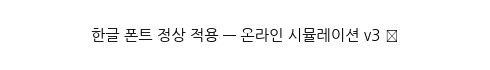

In [1]:
# ============================================================
# 셀 A-2 — 한글 폰트 적용 (런타임 재시작 후 매번 실행)
# ============================================================
import os, matplotlib.pyplot as plt, matplotlib.font_manager as fm
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = 'NanumGothic'
    plt.rcParams['axes.unicode_minus'] = False
    fig, ax = plt.subplots(figsize=(5, 0.8))
    ax.text(0.5, 0.5, '한글 폰트 정상 적용 — 온라인 시뮬레이션 v3 ✅',
            ha='center', va='center', fontsize=11)
    ax.axis('off'); plt.tight_layout(); plt.show(); plt.close()
else:
    print('폰트 없음 → 셀A 실행 후 런타임 재시작')

In [5]:
# ============================================================
# 셀 S0 — 드라이브 마운트 + 경로 자동 탐색 + 클래스 정의
#
# v3 핵심 수정:
#   FEMTO 폴더명은 배포본마다 다름
#     예: Learning_set / Training_set / training(learning)_set 등
#   → os.walk 로 실제 acc_*.csv 가 들어있는 Bearing*_* 폴더를 자동 발견
#   → LEARNING_DIR 을 자동으로 확정
#   이후 모든 셀은 자동 확정된 경로를 사용하므로 수동 수정 불필요
# ============================================================
import os, glob
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.font_manager as fm

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = 'NanumGothic'
    plt.rcParams['axes.unicode_minus'] = False

from google.colab import drive
drive.mount('/content/drive')

# ----------------------------------------------------------------
# Step 1: FEMTO 루트 폴더 후보 (실제 드라이브 구조에 맞게 나열)
# ----------------------------------------------------------------
FEMTO_ROOT_CANDIDATES = [
    '/content/drive/My Drive/Colab Notebooks/RunToFailure_Raw_Data/PRONOSTIA_FEMTO_Bearing',
    '/content/drive/My Drive/Colab Notebooks/RunToFailure_Raw_Data/PRONOSTIA_FEMTO',
    '/content/drive/My Drive/Colab Notebooks/PRONOSTIA_FEMTO_Bearing',
    '/content/drive/My Drive/Colab Notebooks/PRONOSTIA_FEMTO',
    '/content/drive/My Drive/PRONABOA_FEMTO_Bearing',
    '/content/drive/My Drive/PRONOSTIA_FEMTO'
]

# ----------------------------------------------------------------
# Step 2: 실제 Bearing*_* 폴더가 있는 부모 디렉토리를 자동 탐색
# ----------------------------------------------------------------
def find_learning_dir(root_candidates):
    """
    root_candidates 아래를 재귀 탐색해
    acc_*.csv 가 있는 Bearing*_* 폴더가 가장 많은 부모 디렉토리를 반환.
    """
    best_parent = None
    best_count  = 0

    for root_cand in root_candidates:
        if not os.path.exists(root_cand):
            continue
        print(f'  탐색 중: {root_cand}')
        for dirpath, dirnames, filenames in os.walk(root_cand):
            acc_files = [f for f in filenames if f.startswith('acc') and f.endswith('.csv')]
            if len(acc_files) > 0 and os.path.basename(dirpath).startswith('Bearing'):
                parent = os.path.dirname(dirpath)
                # 이 parent 아래 Bearing*_* 폴더가 몇 개인지
                sibling_bearing_dirs = [
                    d for d in os.listdir(parent)
                    if os.path.isdir(os.path.join(parent, d)) and d.startswith('Bearing')
                ]
                if len(sibling_bearing_dirs) > best_count:
                    best_count  = len(sibling_bearing_dirs)
                    best_parent = parent
    return best_parent, best_count

print('=== FEMTO 폴더 자동 탐색 중 ===')
LEARNING_DIR, n_found = find_learning_dir(FEMTO_ROOT_CANDIDATES)

if LEARNING_DIR is None:
    print()
    print('❌ Bearing*_* 폴더를 찾지 못했습니다.')
    print()
    print('해결 방법:')
    print('  1) 아래 셀에서 드라이브 폴더 구조를 직접 확인하세요:')
    print('     !ls "/content/drive/My Drive/Colab Notebooks/"')
    print('  2) Bearing1_1 폴더가 실제로 어디에 있는지 확인한 뒤')
    print('     이 셀 최하단 LEARNING_DIR_OVERRIDE 에 직접 경로를 입력하세요')
    # 수동 오버라이드 (자동 탐색 실패 시 여기에 직접 입력)
    LEARNING_DIR_OVERRIDE = ''   # ← 예: '/content/drive/My Drive/FEMTO/Learning_set'
    if LEARNING_DIR_OVERRIDE:
        LEARNING_DIR = LEARNING_DIR_OVERRIDE
        print(f'\n수동 설정: {LEARNING_DIR}')
    else:
        raise RuntimeError('LEARNING_DIR 을 찾을 수 없습니다. 위 안내를 따라 경로를 설정하세요.')
else:
    print(f'\n✅ LEARNING_DIR 자동 확정: {LEARNING_DIR}')
    print(f'   Bearing 폴더 수: {n_found}개')

# ----------------------------------------------------------------
# Step 3: 실제 베어링 목록 자동 수집
# ----------------------------------------------------------------
ALL_BEARING_DIRS = sorted([
    d for d in os.listdir(LEARNING_DIR)
    if os.path.isdir(os.path.join(LEARNING_DIR, d)) and d.startswith('Bearing')
])

print()
print('=== 발견된 베어링 폴더 & 파일 수 ===')
BEARING_FILE_COUNTS = {}
for b in ALL_BEARING_DIRS:
    bpath = os.path.join(LEARNING_DIR, b)
    files = sorted(glob.glob(os.path.join(bpath, 'acc_*.csv')))
    BEARING_FILE_COUNTS[b] = len(files)
    cond  = b[7] if len(b) > 7 else '?'
    cond_label = {'1': '1800rpm', '2': '1650rpm', '3': '1500rpm'}.get(cond, '?')
    note = '  ← 급성형 의심' if len(files) < 800 else ''
    print(f'  {b}: {len(files)}개 acc파일  [{cond_label}]{note}')

# 6개 기준 베어링 (있는 것만)
# 기존 TARGET 리스트가 현재 LEARNING_DIR에 없는 베어링을 포함하고 있어 BEARINGS가 비게 됨.
# ALL_BEARING_DIRS 에 있는 모든 베어링을 대상으로 하도록 수정.
BEARINGS = [b for b in ALL_BEARING_DIRS if BEARING_FILE_COUNTS.get(b,0)>0]
missing  = [b for b in TARGET if b not in BEARINGS] # TARGET은 ALL_BEARING_DIRS에 포함되지 않는 베어링을 위해 유지
print()
print(f'검증 대상: {BEARINGS}')
if missing:
    print(f'없는 베어링(스킵): {missing}')

# ----------------------------------------------------------------
# 공통 설정
# ----------------------------------------------------------------
SAVE_DIR  = '/content/drive/My Drive/Colab Notebooks/field_iis3dwb/'
os.makedirs(SAVE_DIR, exist_ok=True)

FEMTO_FS  = 25600
COL_H     = 4       # H축 가속도
K_DEFAULT = 6.0
CONSEC    = 5
COND_RPM  = {'1': '1800rpm', '2': '1650rpm', '3': '1500rpm'}
OFFLINE_REF_PCT = {'Bearing1_1': 40.7}  # 알려진 오프라인 기준

# ----------------------------------------------------------------
# 특징 추출 (9개)
# ----------------------------------------------------------------
def extract_features(sig, fs=FEMTO_FS):
    x     = sig.astype(np.float64)
    rms   = np.sqrt(np.mean(x**2))
    peak  = np.max(np.abs(x))
    crest = peak / (rms + 1e-12)
    std   = np.std(x)
    mean  = np.mean(x)
    kurt  = np.mean(((x-mean)/(std+1e-12))**4)
    skew  = np.mean(((x-mean)/(std+1e-12))**3)
    p2p   = np.ptp(x)
    env   = np.abs(x)
    env_rms = np.sqrt(np.mean((env - env.mean())**2))
    fft   = np.abs(np.fft.rfft(x))
    hf    = np.sum(fft[len(fft)//2:]) / (np.sum(fft) + 1e-12)
    return np.array([rms, peak, crest, kurt, skew, p2p, std, env_rms, hf])

FEATURE_NAMES = ['RMS','Peak','Crest','Kurtosis','Skew','P2P','Std','EnvRMS','HF_ratio']

# ----------------------------------------------------------------
# 베어링 데이터 로딩 (구분자 자동판별 + 명확한 에러 메시지)
# ----------------------------------------------------------------
def load_bearing(bearing):
    bpath = os.path.join(LEARNING_DIR, bearing)
    files = sorted(glob.glob(os.path.join(bpath, 'acc_*.csv')))

    if len(files) == 0:
        # 명확한 진단 출력
        print(f'\n❌ {bearing}: acc_*.csv 없음')
        print(f'   찾은 경로: {bpath}')
        print(f'   폴더 존재: {os.path.exists(bpath)}')
        if os.path.exists(bpath):
            all_files = os.listdir(bpath)[:10]
            print(f'   폴더 내 파일(최대10): {all_files}')
        else:
            avail = [d for d in os.listdir(LEARNING_DIR) if d.startswith('Bearing')][:10]
            print(f'   LEARNING_DIR 내 Bearing 폴더: {avail}')
        raise FileNotFoundError(
            f'{bearing} 의 acc_*.csv 파일을 찾을 수 없습니다.\n'
            f'경로: {bpath}\n'
            f'LEARNING_DIR={LEARNING_DIR} 가 올바른지 확인하세요.'
        )

    feats = []
    for f in files:
        try:
            arr = np.loadtxt(f, delimiter=',')
            if arr.ndim != 2 or arr.shape[1] < 5:
                raise ValueError
        except Exception:
            arr = np.loadtxt(f, delimiter=';')
        feats.append(extract_features(arr[:, COL_H]))
    return np.array(feats)  # (N_win, 9)

# ----------------------------------------------------------------
# Mahalanobis 판정기
# ----------------------------------------------------------------
class BaselineDetector:
    def __init__(self, K=6.0, consec=5):
        self.K = K; self.consec = consec
        self.mu = self.inv_cov = self.thr = None
        self._run = 0

    def fit(self, base_feats):
        self.mu      = base_feats.mean(axis=0)
        cov          = np.cov(base_feats.T) + np.eye(base_feats.shape[1]) * 1e-6
        self.inv_cov = np.linalg.inv(cov)
        d_base       = self._dist_batch(base_feats)
        self.thr     = d_base.mean() + self.K * d_base.std()

    def _dist_batch(self, X):
        diff = X - self.mu
        return np.sqrt(np.einsum('ij,jk,ik->i', diff, self.inv_cov, diff))

    def step(self, feat):
        diff = feat - self.mu
        d    = float(np.sqrt(diff @ self.inv_cov @ diff))
        if d > self.thr:
            self._run += 1
            alarm = self._run >= self.consec
        else:
            self._run = 0; alarm = False
        return d, alarm

# ----------------------------------------------------------------
# 공통 실행 함수
# ----------------------------------------------------------------
def run_fixed_bw(F, bw, K=K_DEFAULT, consec=CONSEC):
    N = len(F)
    if bw >= N - consec:
        return {'alarm_at': None, 'dists': [], 'thr': None, 'reason': '등록>수명', 'bw': bw, 'N': N}
    det = BaselineDetector(K, consec)
    det.fit(F[:bw])
    dists, alarm_at = [], None
    for i in range(bw, N):
        d, a = det.step(F[i])
        dists.append(d)
        if a and alarm_at is None:
            alarm_at = i
    return {'alarm_at': alarm_at, 'dists': dists, 'thr': det.thr, 'bw': bw, 'N': N}

# ----------------------------------------------------------------
# 적응형 등록 종료
# ----------------------------------------------------------------
def adaptive_register(F, min_win=90, max_win=600,
                       check_every=30, tol=0.02,
                       stable_hits=2, max_life_r=0.30):
    N   = len(F)
    cap = min(max_win, max(min_win, int(N * max_life_r)))
    prev_mu = prev_sd = None
    hits = 0
    for w in range(min_win, cap + 1):
        cur = F[:w]
        mu  = cur.mean(0)
        sd  = cur.std(0) + 1e-12
        if prev_mu is not None and w % check_every == 0:
            d_mu = np.mean(np.abs((mu - prev_mu) / (np.abs(prev_mu) + 1e-9)))
            d_sd = np.mean(np.abs((sd - prev_sd) / prev_sd))
            if d_mu < tol and d_sd < tol:
                hits += 1
                if hits >= stable_hits:
                    return w, '수렴'
            else:
                hits = 0
        prev_mu, prev_sd = mu, sd
    reason = '수명캡' if cap < max_win else '상한도달'
    return cap, reason

print()
print('✅ S0 완료 — 경로 자동 확정 + 클래스 정의')
print(f'   LEARNING_DIR = {LEARNING_DIR}')
print(f'   검증 대상 베어링: {BEARINGS}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
=== FEMTO 폴더 자동 탐색 중 ===
  탐색 중: /content/drive/My Drive/Colab Notebooks/RunToFailure_Raw_Data/PRONOSTIA_FEMTO_Bearing

✅ LEARNING_DIR 자동 확정: /content/drive/My Drive/Colab Notebooks/RunToFailure_Raw_Data/PRONOSTIA_FEMTO_Bearing/Validation(Full_Test)_Set
   Bearing 폴더 수: 11개

=== 발견된 베어링 폴더 & 파일 수 ===
  Bearing1_3: 2375개 acc파일  [1800rpm]
  Bearing1_4: 1428개 acc파일  [1800rpm]
  Bearing1_5: 2463개 acc파일  [1800rpm]
  Bearing1_6: 2448개 acc파일  [1800rpm]
  Bearing1_7: 2259개 acc파일  [1800rpm]
  Bearing2_3: 1955개 acc파일  [1650rpm]
  Bearing2_4: 751개 acc파일  [1650rpm]  ← 급성형 의심
  Bearing2_5: 2311개 acc파일  [1650rpm]
  Bearing2_6: 701개 acc파일  [1650rpm]  ← 급성형 의심
  Bearing2_7: 230개 acc파일  [1650rpm]  ← 급성형 의심
  Bearing3_3: 434개 acc파일  [1500rpm]  ← 급성형 의심

검증 대상: ['Bearing1_3', 'Bearing1_4', 'Bearing1_5', 'Bearing1_6', 'Bearing1_7', 'Bearing2_3', 'Bearing2_4', 'Bearing2_5', 'Bear

In [6]:
# ============================================================
# 셀 S0-debug — 경로 탐색 실패 시 수동 확인용 (선택)
# S0 에서 LEARNING_DIR 이 자동 확정됐으면 이 셀은 건너뜀
# ============================================================

# 1) 드라이브 최상위 구조 확인
print('=== My Drive > Colab Notebooks 폴더 목록 ===')
base_nb = '/content/drive/My Drive/Colab Notebooks'
if os.path.exists(base_nb):
    for item in sorted(os.listdir(base_nb)):
        full = os.path.join(base_nb, item)
        tag  = '[DIR]' if os.path.isdir(full) else '[FILE]'
        print(f'  {tag} {item}')
else:
    print('Colab Notebooks 폴더 없음 — 경로 확인 필요')
    for item in sorted(os.listdir('/content/drive/My Drive'))[:20]:
        print(f'  {item}')

print()
print('=== FEMTO 루트 후보 존재 여부 ===')
for c in FEMTO_ROOT_CANDIDATES:
    exists = os.path.exists(c)
    print(f'  {"✅" if exists else "❌"} {c}')
    if exists:
        sub = [d for d in os.listdir(c) if os.path.isdir(os.path.join(c, d))][:8]
        print(f'     하위 폴더: {sub}')

print()
print('위 출력에서 Bearing1_1 이 있는 폴더 경로를 복사해')
print('S0 셀의 LEARNING_DIR_OVERRIDE 에 붙여넣고 S0을 재실행하세요.')

=== My Drive > Colab Notebooks 폴더 목록 ===
  [DIR] (CWRU)_AI_KimBanjang_LITE_v2
  [DIR] (휴지통)_NPU없는 버전, 기준미달 버전 등
  [DIR] AI KIM_LITE_Dev_note_260717
  [DIR] AI_KimBanjang_Paderborn
  [DIR] AI_KimBanjang_binary
  [DIR] AI_KimBanjang_cls3
  [FILE] AI_KimBanjang_onsite_validation.ipynb
  [DIR] AI_KimBanjang_v4
  [DIR] CWRU_original_file_mat_20260504
  [DIR] Google_Colab_복사본
  [FILE] MCSA 정상상태 FFT 검증 Simulation.ipynb
  [DIR] Paderborn_raw_mat
  [DIR] RunToFailure_Raw_Data
  [DIR] field_iis3dwb
  [DIR] onsite_r2f_femto
  [DIR] onsite_r2f_ims

=== FEMTO 루트 후보 존재 여부 ===
  ✅ /content/drive/My Drive/Colab Notebooks/RunToFailure_Raw_Data/PRONOSTIA_FEMTO_Bearing
     하위 폴더: ['Validation(Full_Test)_Set', 'Test(Test)_set', 'Training(Learning)_set']
  ❌ /content/drive/My Drive/Colab Notebooks/RunToFailure_Raw_Data/PRONOSTIA_FEMTO
  ❌ /content/drive/My Drive/Colab Notebooks/PRONOSTIA_FEMTO_Bearing
  ❌ /content/drive/My Drive/Colab Notebooks/PRONOSTIA_FEMTO
  ❌ /co

처리 중: Bearing1_3... ✅  (N=2375, 등록비율=17.7%)
처리 중: Bearing1_4... ✅  (N=1428, 등록비율=29.4%)
처리 중: Bearing1_5... ✅  (N=2463, 등록비율=17.1%)
처리 중: Bearing1_6... ✅  (N=2448, 등록비율=17.2%)
처리 중: Bearing1_7... ✅  (N=2259, 등록비율=18.6%)
처리 중: Bearing2_3... ⚠️ 리드타임 부족  (N=1955, 등록비율=21.5%)
처리 중: Bearing2_4... ⚠️ 리드타임 부족  (N=751, 등록비율=55.9%)
처리 중: Bearing2_5... ✅  (N=2311, 등록비율=18.2%)
처리 중: Bearing2_6... ⚠️ 리드타임 부족  (N=701, 등록비율=59.9%)
처리 중: Bearing2_7... ❌ 등록>수명
처리 중: Bearing3_3... ⚠️ 리드타임 부족  (N=434, 등록비율=96.8%)


/tmp/ipykernel_6535/2067889710.py:87: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) NanumGothic.
  plt.tight_layout()
/tmp/ipykernel_6535/2067889710.py:87: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) NanumGothic.
  plt.tight_layout()
/tmp/ipykernel_6535/2067889710.py:87: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) NanumGothic.
  plt.tight_layout()
/tmp/ipykernel_6535/2067889710.py:87: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) NanumGothic.
  plt.tight_layout()
/tmp/ipykernel_6535/2067889710.py:89: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) NanumGothic.
  plt.savefig(out_420, dpi=120, bbox_inches='tight')
/tmp/ipykernel_6535/2067889710.py:89: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) NanumGothic.
  plt.savefig(out_420, dpi=120, bbox_inches='tight')
/tmp/ipykernel_6535/2067889710.py:89: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) 

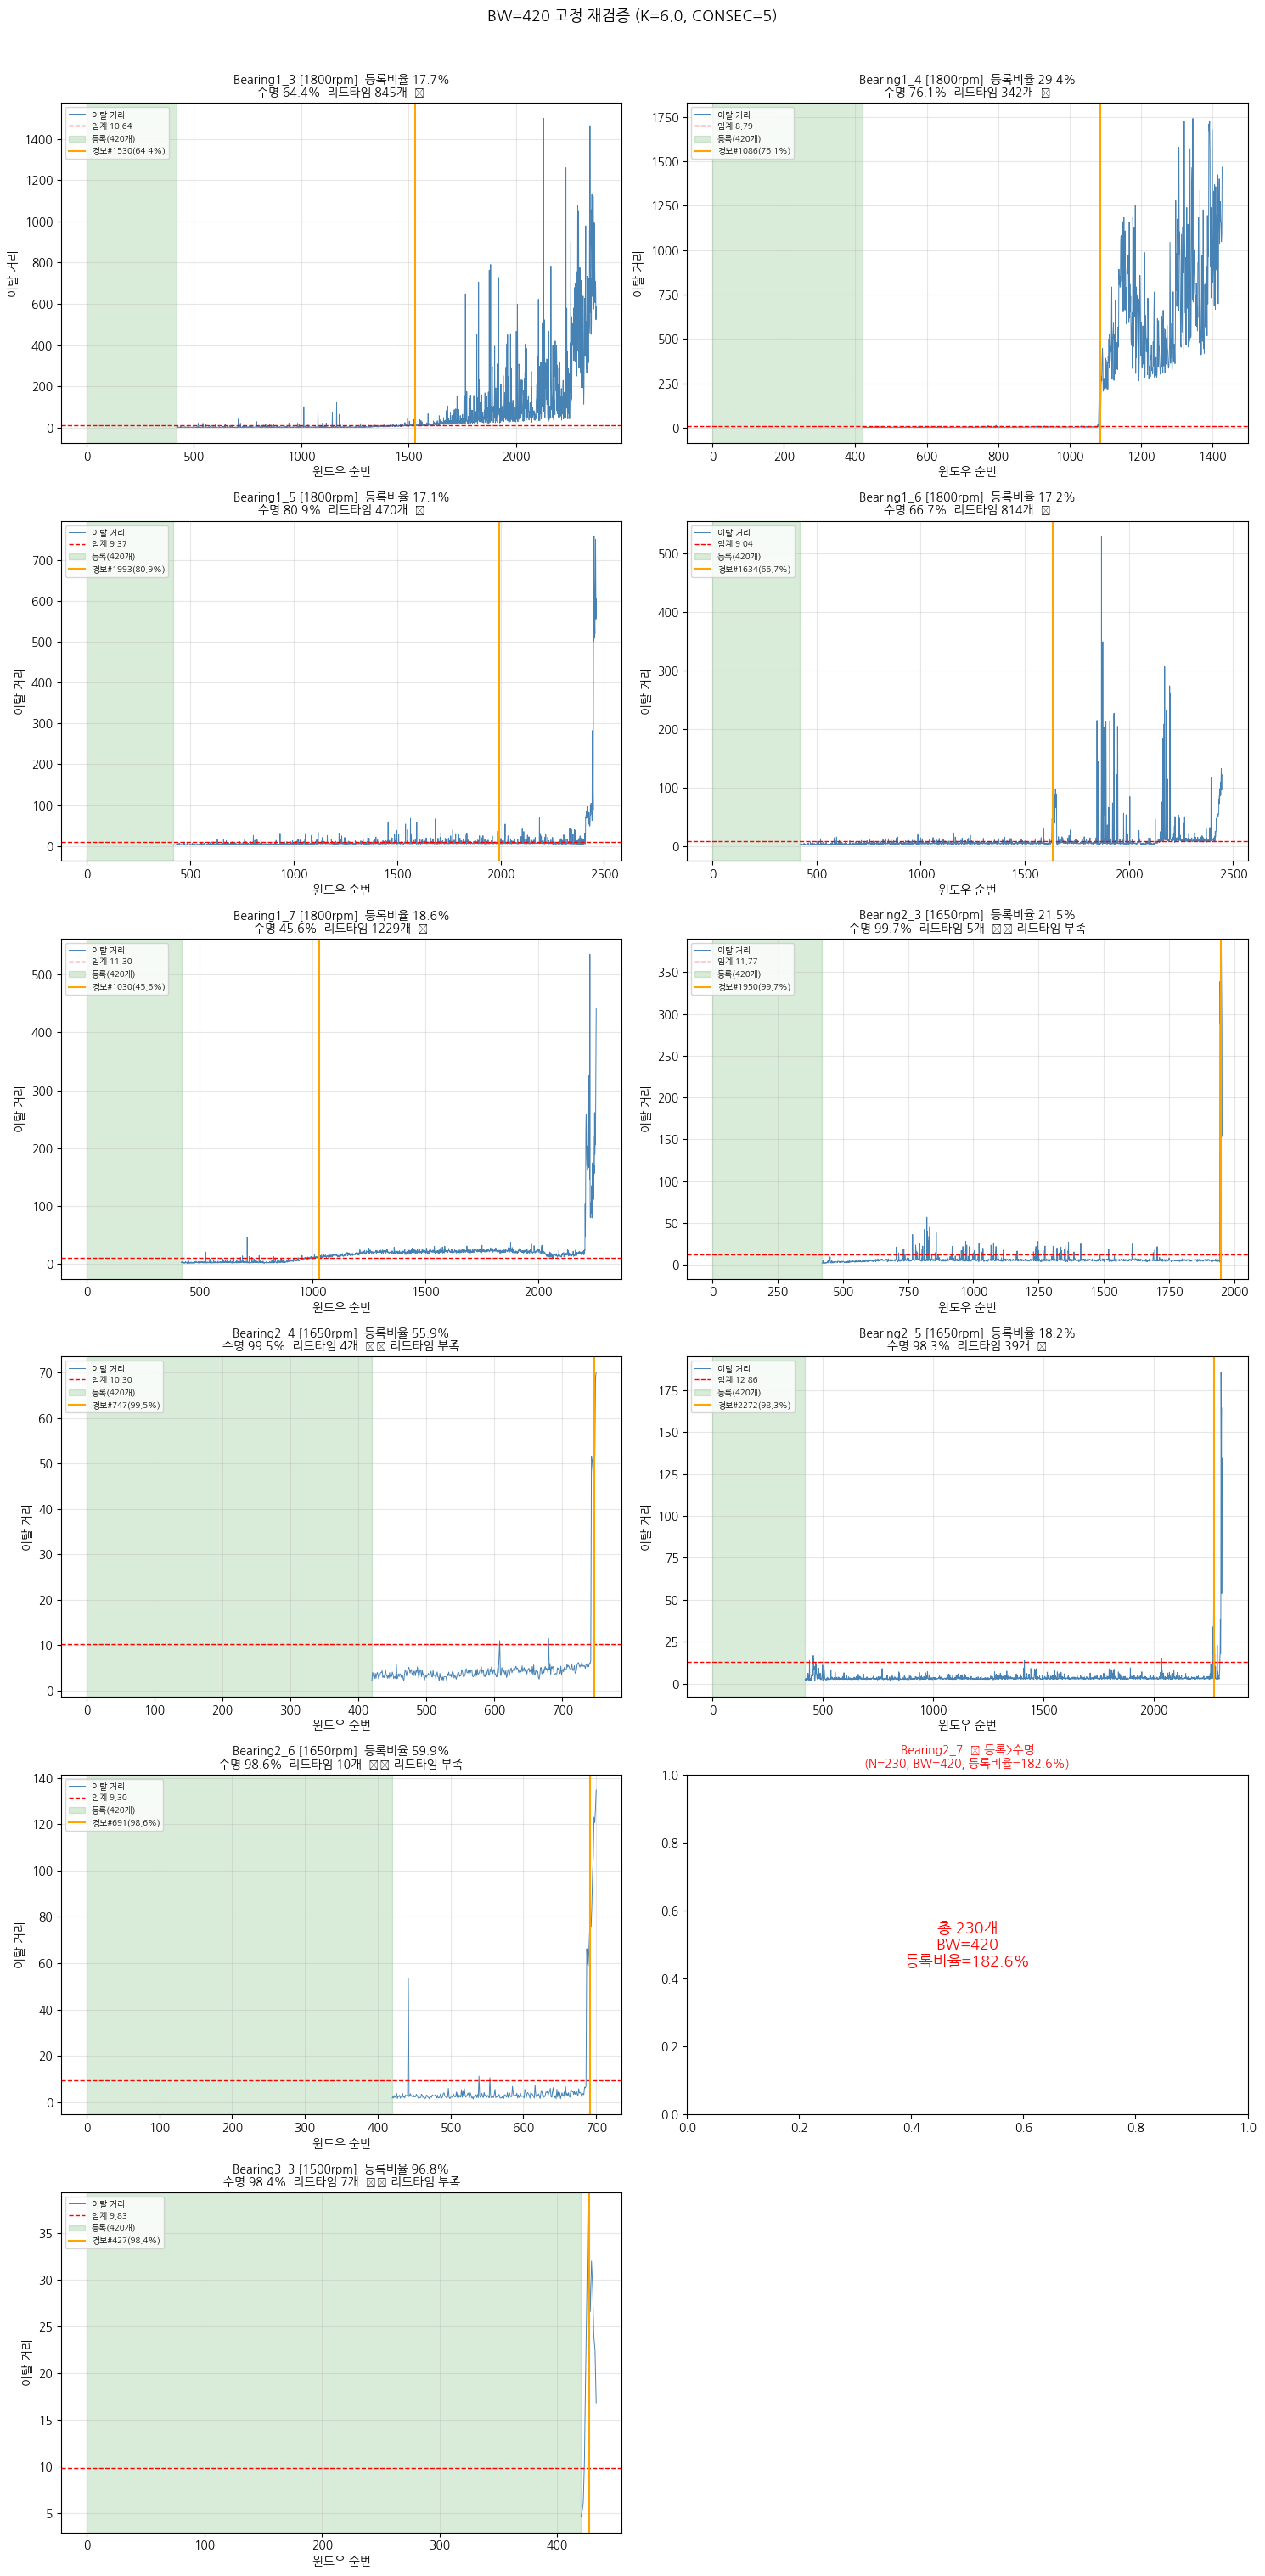

저장: /content/drive/My Drive/Colab Notebooks/field_iis3dwb/online_sim_all_bw420.png

=== BW=420 고정 재검증 결과 ===
       베어링      조건  총윈도우  BW  경보# 수명%(온라인) 오프라인기준%  차이  리드타임(개)   등록비율         판정
Bearing1_3 1800rpm  2375 420 1530    64.4%       -   -      845  17.7%          ✅
Bearing1_4 1800rpm  1428 420 1086    76.1%       -   -      342  29.4%          ✅
Bearing1_5 1800rpm  2463 420 1993    80.9%       -   -      470  17.1%          ✅
Bearing1_6 1800rpm  2448 420 1634    66.7%       -   -      814  17.2%          ✅
Bearing1_7 1800rpm  2259 420 1030    45.6%       -   -     1229  18.6%          ✅
Bearing2_3 1650rpm  1955 420 1950    99.7%       -   -        5  21.5% ⚠️ 리드타임 부족
Bearing2_4 1650rpm   751 420  747    99.5%       -   -        4  55.9% ⚠️ 리드타임 부족
Bearing2_5 1650rpm  2311 420 2272    98.3%       -   -       39  18.2%          ✅
Bearing2_6 1650rpm   701 420  691    98.6%       -   -       10  59.9% ⚠️ 리드타임 부족
Bearing2_7 1650rpm   230 420    -        -       - NaN        0 182.6% 

In [7]:
# ============================================================
# 셀 S3-420 — BW=420 고정 재검증
# 핵심 확인: '등록비율' 컬럼
#   급성형(N 작은 베어링)에서 80%+ → 리드타임 소멸 확인
#   → 이것이 적응형이 필요한 이유를 데이터로 증명
# ============================================================
BW_FIXED = 420

rows_420 = []
n_bear   = len(BEARINGS)
ncols    = 2
nrows    = (n_bear + 1) // 2
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5*nrows))
axes_flat = axes.ravel() if n_bear > 1 else [axes]

for ax, bearing in zip(axes_flat, BEARINGS):
    cond = bearing[7]
    print(f'처리 중: {bearing}...', end=' ')

    F   = load_bearing(bearing)
    N   = len(F)
    res = run_fixed_bw(F, BW_FIXED)

    reg_ratio_val = round(100 * BW_FIXED / N, 1) if N else 0
    reg_ratio_str = f'{reg_ratio_val}%'

    if res.get('reason') == '등록>수명':
        rows_420.append({
            '베어링': bearing, '조건': COND_RPM.get(cond,'?'),
            '총윈도우': N, 'BW': BW_FIXED,
            '경보#': '-', '수명%(온라인)': '-',
            '오프라인기준%': OFFLINE_REF_PCT.get(bearing, '-'),
            '리드타임(개)': 0,
            '등록비율': reg_ratio_str,
            '판정': '❌ 등록>수명'
        })
        ax.set_title(f'{bearing}  ❌ 등록>수명\n(N={N}, BW={BW_FIXED}, 등록비율={reg_ratio_str})',
                     fontsize=10, color='red')
        ax.text(0.5, 0.5, f'총 {N}개\nBW={BW_FIXED}\n등록비율={reg_ratio_str}',
                ha='center', va='center', transform=ax.transAxes, fontsize=13, color='red')
        print('❌ 등록>수명')
        continue

    alarm_at  = res['alarm_at']
    dists     = res['dists']
    thr       = res['thr']
    life_pct  = round(alarm_at / N * 100, 1) if alarm_at else None
    lead      = (N - alarm_at) if alarm_at else 0
    offline   = OFFLINE_REF_PCT.get(bearing)
    diff_str  = f'{abs(life_pct - offline):.1f}%p' if (life_pct and offline) else '-'
    verdict   = '✅' if alarm_at and lead > 10 else ('⚠️ 리드타임 부족' if alarm_at else '❌ 경보없음')

    rows_420.append({
        '베어링': bearing, '조건': COND_RPM.get(cond,'?'),
        '총윈도우': N, 'BW': BW_FIXED,
        '경보#': alarm_at if alarm_at else '-',
        '수명%(온라인)': f'{life_pct}%' if life_pct else '-',
        '오프라인기준%': f'{offline}%' if offline else '-',
        '차이': diff_str,
        '리드타임(개)': lead,
        '등록비율': reg_ratio_str,
        '판정': verdict
    })

    x_plot = list(range(BW_FIXED, N))
    ax.plot(x_plot, dists, color='steelblue', lw=0.7, label='이탈 거리')
    ax.axhline(thr, color='red', ls='--', lw=1, label=f'임계 {thr:.2f}')
    ax.axvspan(0, BW_FIXED, color='green', alpha=0.15, label=f'등록({BW_FIXED}개)')
    if alarm_at:
        ax.axvline(alarm_at, color='orange', lw=1.5,
                   label=f'경보#{alarm_at}({life_pct}%)')
    ax.set_title(
        f'{bearing} [{COND_RPM.get(cond,"")}]  등록비율 {reg_ratio_str}\n'
        + (f'수명 {life_pct}%  리드타임 {lead}개  {verdict}' if alarm_at else '경보없음'),
        fontsize=10
    )
    ax.set_xlabel('윈도우 순번'); ax.set_ylabel('이탈 거리')
    ax.legend(loc='upper left', fontsize=7); ax.grid(alpha=0.3)
    print(f'{verdict}  (N={N}, 등록비율={reg_ratio_str})')

# 남은 subplot 숨기기
for ax in axes_flat[n_bear:]:
    ax.set_visible(False)

plt.suptitle(f'BW=420 고정 재검증 (K={K_DEFAULT}, CONSEC={CONSEC})',
             fontsize=13, y=1.01)
plt.tight_layout()
out_420 = SAVE_DIR + 'online_sim_all_bw420.png'
plt.savefig(out_420, dpi=120, bbox_inches='tight')
plt.show()
print(f'저장: {out_420}')

df_420 = pd.DataFrame(rows_420)
pd.set_option('display.width', 220); pd.set_option('display.max_rows', None)
print()
print('=== BW=420 고정 재검증 결과 ===')
print(df_420.to_string(index=False))
print()
print('[눈으로 확인] 등록비율 컬럼:')
print('  급성형(N 작은 베어링)에서 80%+ → 리드타임 소멸 = 적응형 필요 이유')
print('  점진형(N 큰 베어링)에서 낮은 등록비율 + 오프라인 기준 근접 여부')

처리 중: Bearing1_3... BW=150(수렴) → ✅
처리 중: Bearing1_4... BW=150(수렴) → ✅
처리 중: Bearing1_5... BW=210(수렴) → ✅
처리 중: Bearing1_6... BW=150(수렴) → ✅
처리 중: Bearing1_7... BW=150(수렴) → ✅
처리 중: Bearing2_3... BW=150(수렴) → ✅
처리 중: Bearing2_4... BW=150(수렴) → ✅
처리 중: Bearing2_5... BW=150(수렴) → ✅
처리 중: Bearing2_6... BW=150(수렴) → ✅
처리 중: Bearing2_7... BW=90(수명캡) → ⚠️ 리드타임 부족
처리 중: Bearing3_3... BW=130(수명캡) → ✅


/tmp/ipykernel_6535/580149385.py:98: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) NanumGothic.
  plt.tight_layout()
/tmp/ipykernel_6535/580149385.py:98: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) NanumGothic.
  plt.tight_layout()
/tmp/ipykernel_6535/580149385.py:98: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) NanumGothic.
  plt.tight_layout()
/tmp/ipykernel_6535/580149385.py:100: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) NanumGothic.
  plt.savefig(out_adapt, dpi=120, bbox_inches='tight')
/tmp/ipykernel_6535/580149385.py:100: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) NanumGothic.
  plt.savefig(out_adapt, dpi=120, bbox_inches='tight')
/tmp/ipykernel_6535/580149385.py:100: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) NanumGothic.
  plt.savefig(out_adapt, dpi=120, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPyth

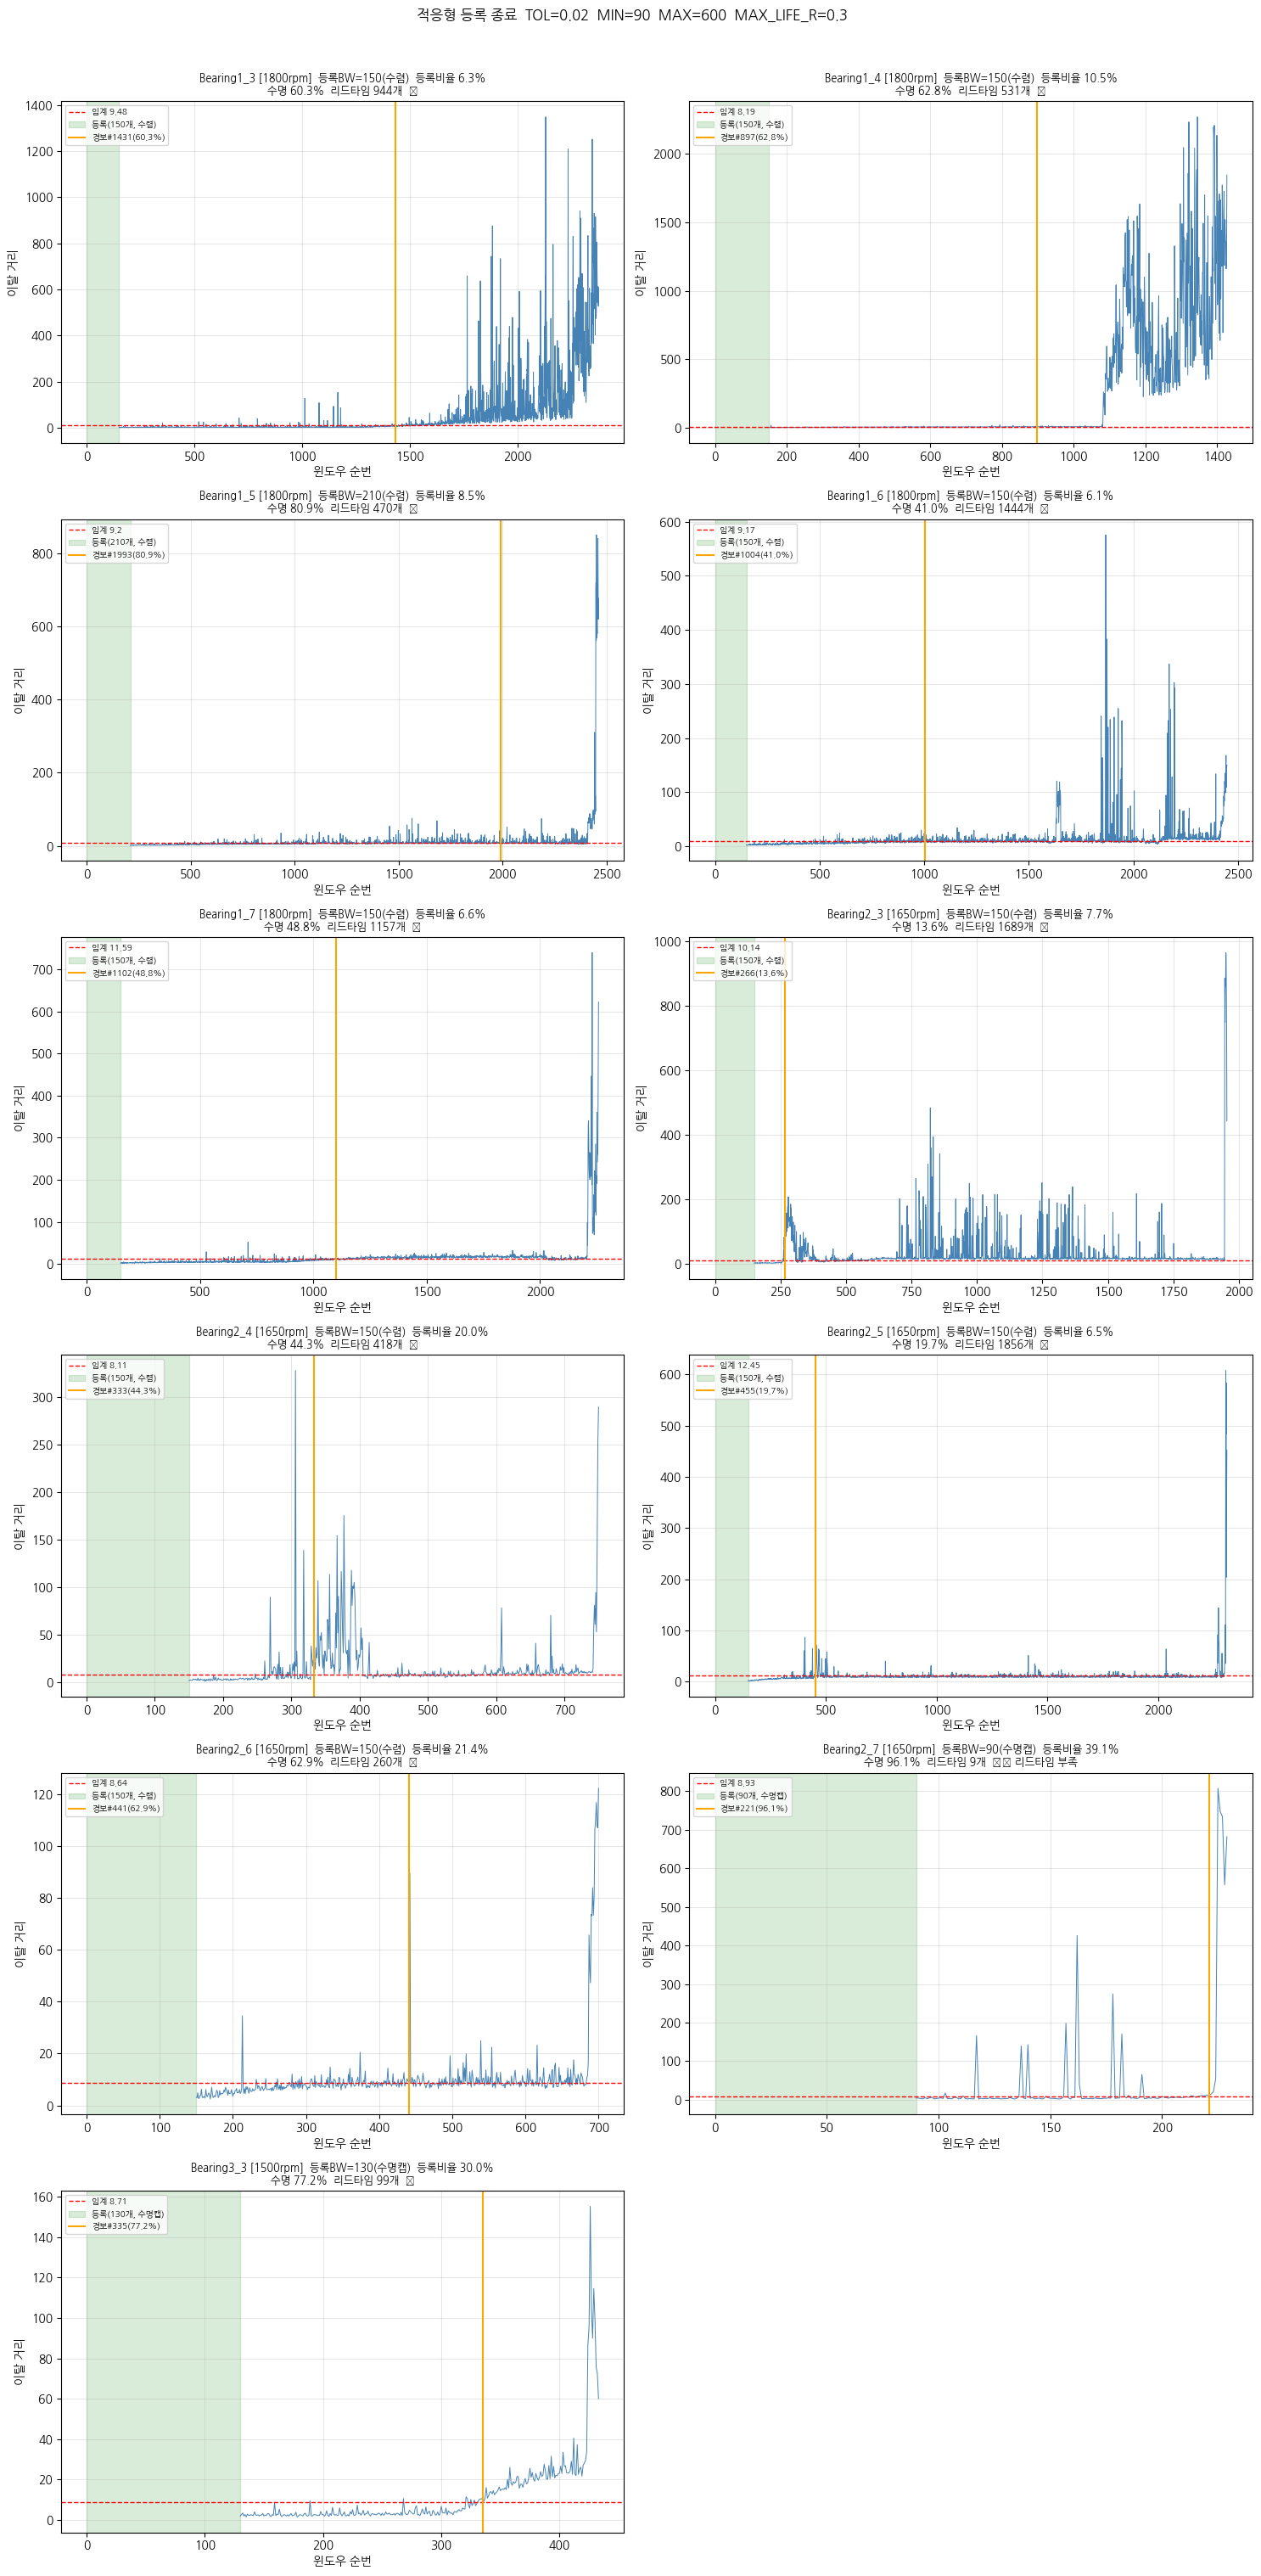

저장: /content/drive/My Drive/Colab Notebooks/field_iis3dwb/online_sim_all_adaptive.png

=== 적응형 등록 결과 ===
       베어링      조건  총윈도우  등록BW(적응형) 종료사유  경보# 수명%(온라인) 오프라인기준% 차이  리드타임(개)  등록비율         판정
Bearing1_3 1800rpm  2375        150   수렴 1431    60.3%       -  -      944  6.3%          ✅
Bearing1_4 1800rpm  1428        150   수렴  897    62.8%       -  -      531 10.5%          ✅
Bearing1_5 1800rpm  2463        210   수렴 1993    80.9%       -  -      470  8.5%          ✅
Bearing1_6 1800rpm  2448        150   수렴 1004    41.0%       -  -     1444  6.1%          ✅
Bearing1_7 1800rpm  2259        150   수렴 1102    48.8%       -  -     1157  6.6%          ✅
Bearing2_3 1650rpm  1955        150   수렴  266    13.6%       -  -     1689  7.7%          ✅
Bearing2_4 1650rpm   751        150   수렴  333    44.3%       -  -      418 20.0%          ✅
Bearing2_5 1650rpm  2311        150   수렴  455    19.7%       -  -     1856  6.5%          ✅
Bearing2_6 1650rpm   701        150   수렴  441    62.9%       -  -  

In [8]:
# ============================================================
# 셀 S3-ADAPT — 적응형 등록 종료 + 판정
# 핵심 확인: 점진형↔급성형이 등록 BW 자동 분기되는가
# ============================================================

# ================ 튜닝 파라미터 ================
MIN_WIN      = 90     # 하한 (특징9 × 10배)
MAX_WIN      = 600    # 상한 (무한 대기 방지)
CHECK_EVERY  = 30     # 수렴 검사 주기
TOL          = 0.02   # 상대변화 허용 기준 2%
STABLE_HITS  = 2      # 연속 수렴 횟수
MAX_LIFE_R   = 0.30   # 수명 비율 캡 (시뮬 전용)
# ================================================
# 튜닝 가이드:
#   Bearing1_1이 너무 일찍 경보 → TOL=0.01로 조이기
#   급성형이 등록>수명으로 죽으면 → MIN_WIN=60으로 낮추기
# ================================================

rows_adapt = []
adapt_info = {}   # 시각화용

n_bear  = len(BEARINGS)
ncols   = 2
nrows   = (n_bear + 1) // 2
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5*nrows))
axes_flat = axes.ravel() if n_bear > 1 else [axes]

for ax, bearing in zip(axes_flat, BEARINGS):
    cond = bearing[7]
    print(f'처리 중: {bearing}...', end=' ')

    F = load_bearing(bearing)
    N = len(F)

    bw, reason = adaptive_register(
        F, min_win=MIN_WIN, max_win=MAX_WIN,
        check_every=CHECK_EVERY, tol=TOL,
        stable_hits=STABLE_HITS, max_life_r=MAX_LIFE_R
    )
    adapt_info[bearing] = (bw, reason)

    res      = run_fixed_bw(F, bw)
    alarm_at = res['alarm_at']
    dists    = res.get('dists', [])
    thr      = res.get('thr')
    life_pct = round(alarm_at / N * 100, 1) if alarm_at else None
    lead     = (N - alarm_at) if alarm_at else 0
    reg_ratio_val = round(100 * bw / N, 1)
    offline  = OFFLINE_REF_PCT.get(bearing)
    diff_str = (str(round(abs(life_pct - offline), 1)) + '%p') if (life_pct and offline) else '-'
    verdict  = '✅' if alarm_at and lead > 10 else ('⚠️ 리드타임 부족' if alarm_at else '❌ 경보없음')

    rows_adapt.append({
        '베어링': bearing, '조건': COND_RPM.get(cond, '?'),
        '총윈도우': N,
        '등록BW(적응형)': bw, '종료사유': reason,
        '경보#': alarm_at if alarm_at else '-',
        '수명%(온라인)': (str(life_pct) + '%') if life_pct else '-',
        '오프라인기준%': (str(offline) + '%') if offline else '-',
        '차이': diff_str,
        '리드타임(개)': lead,
        '등록비율': str(reg_ratio_val) + '%',
        '판정': verdict
    })

    x_plot = list(range(bw, N))
    if dists:
        ax.plot(x_plot, dists, color='steelblue', lw=0.7)
    if thr:
        ax.axhline(thr, color='red', ls='--', lw=1,
                   label='임계 ' + str(round(thr, 2)))
    ax.axvspan(0, bw, color='green', alpha=0.15,
               label='등록(' + str(bw) + '개, ' + reason + ')')
    if alarm_at:
        ax.axvline(alarm_at, color='orange', lw=1.5,
                   label='경보#' + str(alarm_at) + '(' + str(life_pct) + '%)')

    # f-string 줄바꿈 대신 변수로 조립 (SyntaxError 방지)
    cond_label  = COND_RPM.get(cond, '')
    title_line1 = bearing + ' [' + cond_label + ']  등록BW=' + str(bw) + '(' + reason + ')  등록비율 ' + str(reg_ratio_val) + '%'
    if alarm_at:
        title_line2 = '수명 ' + str(life_pct) + '%  리드타임 ' + str(lead) + '개  ' + verdict
    else:
        title_line2 = '경보없음'
    ax.set_title(title_line1 + '\n' + title_line2, fontsize=9)
    ax.set_xlabel('윈도우 순번'); ax.set_ylabel('이탈 거리')
    ax.legend(loc='upper left', fontsize=7); ax.grid(alpha=0.3)
    print('BW=' + str(bw) + '(' + reason + ') → ' + verdict)

for ax in axes_flat[n_bear:]:
    ax.set_visible(False)

suptitle_str = ('적응형 등록 종료  TOL=' + str(TOL)
                + '  MIN=' + str(MIN_WIN)
                + '  MAX=' + str(MAX_WIN)
                + '  MAX_LIFE_R=' + str(MAX_LIFE_R))
plt.suptitle(suptitle_str, fontsize=12, y=1.01)
plt.tight_layout()
out_adapt = SAVE_DIR + 'online_sim_all_adaptive.png'
plt.savefig(out_adapt, dpi=120, bbox_inches='tight')
plt.show()
print('저장: ' + out_adapt)

df_adapt = pd.DataFrame(rows_adapt)
print()
print('=== 적응형 등록 결과 ===')
print(df_adapt.to_string(index=False))
print()
print('[자동 분기 확인]')
print('  점진형(1_1, 2_2): 등록BW 크게(300~450) → 임계 안정')
print('  급성형(짧은 N): 등록BW 작게(90~150) → 등록비율 낮아 리드타임 확보')

  등록 방식 3종 종합 비교
  이상: 점진형=30~50% 경보, 급성형=리드타임 확보, 등록비율 낮을수록 좋음
       베어링  총윈도우 BW120_수명%  BW120_리드 BW120_등록비율 BW420_수명%  BW420_리드 BW420_등록비율   BW420_판정  적응BW 적응_종료사유 적응_수명%  적응_리드 적응_등록비율      적응_판정
Bearing1_3  2375     60.3%       944       5.1%     64.4%       845      17.7%          ✅   150      수렴  60.3%    944    6.3%          ✅
Bearing1_4  1428     54.1%       656       8.4%     76.1%       342      29.4%          ✅   150      수렴  62.8%    531   10.5%          ✅
Bearing1_5  2463     80.9%       470       4.9%     80.9%       470      17.1%          ✅   210      수렴  80.9%    470    8.5%          ✅
Bearing1_6  2448     34.6%      1601       4.9%     66.7%       814      17.2%          ✅   150      수렴  41.0%   1444    6.1%          ✅
Bearing1_7  2259     48.8%      1156       5.3%     45.6%      1229      18.6%          ✅   150      수렴  48.8%   1157    6.6%          ✅
Bearing2_3  1955     13.6%      1689       6.1%     99.7%         5      21.5% ⚠️ 리드타임 부족   150      수렴  13.6%   1

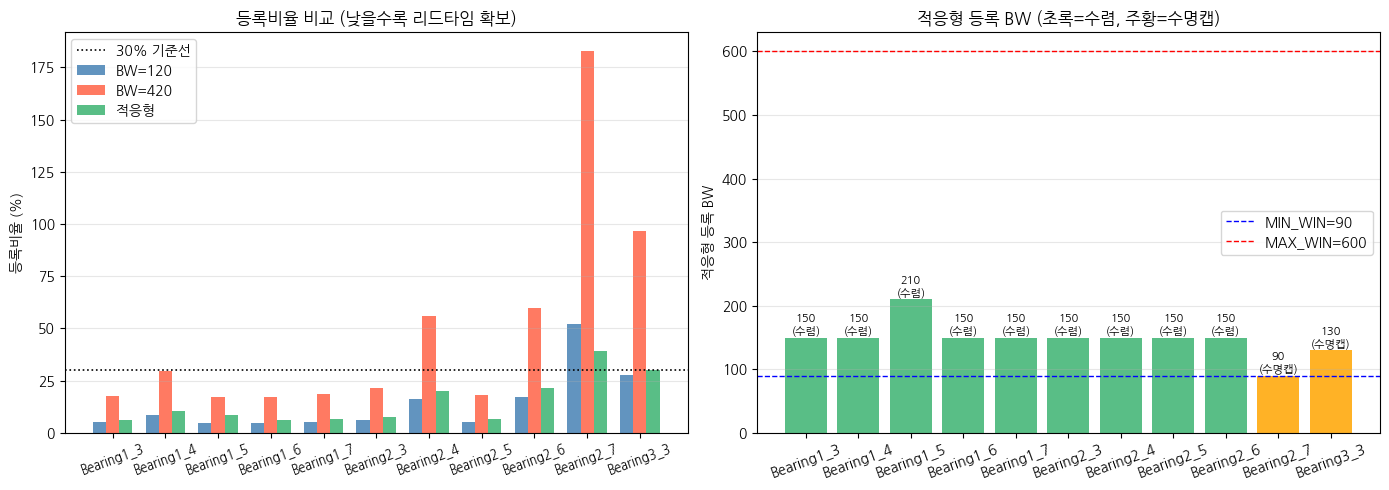

저장: /content/drive/My Drive/Colab Notebooks/field_iis3dwb/online_sim_comparison.png


In [9]:
# ============================================================
# 셀 CMP — 3방식 종합 비교표 + 시각화
# BW=120 vs BW=420 vs 적응형
# ============================================================

def parse_pct(s):
    try: return float(str(s).replace('%',''))
    except: return float('nan')

# BW=120 재실행
rows_120 = []
for bearing in BEARINGS:
    F  = load_bearing(bearing)
    N  = len(F)
    r  = run_fixed_bw(F, 120)
    al = r.get('alarm_at')
    lp = round(al/N*100, 1) if al else None
    rows_120.append({
        '베어링':         bearing,
        'BW120_수명%':    f'{lp}%' if lp else '-',
        'BW120_리드':     (N-al) if al else 0,
        'BW120_등록비율': f'{round(100*120/N,1)}%'
    })

# 병합
cmp_rows = []
for bearing in BEARINGS:
    r120 = next((r for r in rows_120  if r['베어링']==bearing), {})
    r420 = next((r for r in rows_420  if r['베어링']==bearing), {})
    rAda = next((r for r in rows_adapt if r['베어링']==bearing), {})
    cmp_rows.append({
        '베어링':         bearing,
        '총윈도우':       r420.get('총윈도우','-'),
        'BW120_수명%':    r120.get('BW120_수명%','-'),
        'BW120_리드':     r120.get('BW120_리드','-'),
        'BW120_등록비율': r120.get('BW120_등록비율','-'),
        'BW420_수명%':    r420.get('수명%(온라인)','-'),
        'BW420_리드':     r420.get('리드타임(개)','-'),
        'BW420_등록비율': r420.get('등록비율','-'),
        'BW420_판정':     r420.get('판정','-'),
        '적응BW':         rAda.get('등록BW(적응형)','-'),
        '적응_종료사유':  rAda.get('종료사유','-'),
        '적응_수명%':     rAda.get('수명%(온라인)','-'),
        '적응_리드':      rAda.get('리드타임(개)','-'),
        '적응_등록비율':  rAda.get('등록비율','-'),
        '적응_판정':      rAda.get('판정','-'),
    })

df_cmp = pd.DataFrame(cmp_rows)
print('=' * 80)
print('  등록 방식 3종 종합 비교')
print('  이상: 점진형=30~50% 경보, 급성형=리드타임 확보, 등록비율 낮을수록 좋음')
print('=' * 80)
print(df_cmp.to_string(index=False))

df_cmp.to_csv(SAVE_DIR + 'online_sim_comparison.csv', index=False, encoding='utf-8-sig')
print(f'\n저장: {SAVE_DIR}online_sim_comparison.csv')

# 등록비율 바 차트
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(BEARINGS))
w = 0.25

ax0 = axes[0]
r120_vals = [parse_pct(next((r['BW120_등록비율'] for r in rows_120 if r['베어링']==b), 'nan')) for b in BEARINGS]
r420_vals = [parse_pct(next((r.get('등록비율','nan') for r in rows_420 if r['베어링']==b), 'nan')) for b in BEARINGS]
rAda_vals = [parse_pct(next((r.get('등록비율','nan') for r in rows_adapt if r['베어링']==b), 'nan')) for b in BEARINGS]

ax0.bar(x-w, r120_vals, width=w, label='BW=120', color='steelblue', alpha=0.85)
ax0.bar(x,   r420_vals, width=w, label='BW=420', color='tomato',    alpha=0.85)
ax0.bar(x+w, rAda_vals, width=w, label='적응형', color='mediumseagreen', alpha=0.85)
ax0.axhline(30, color='black', ls=':', lw=1.2, label='30% 기준선')
ax0.set_xticks(x); ax0.set_xticklabels(BEARINGS, rotation=20, fontsize=9)
ax0.set_ylabel('등록비율 (%)'); ax0.set_title('등록비율 비교 (낮을수록 리드타임 확보)')
ax0.legend(); ax0.grid(axis='y', alpha=0.3)

# 적응형 BW 절대값 바 (색상: 수렴=초록, 수명캡=주황, 상한도달=회색)
ax1 = axes[1]
adapt_bw_vals = [next((r['등록BW(적응형)'] for r in rows_adapt if r['베어링']==b), 0) for b in BEARINGS]
adapt_reasons = [next((r['종료사유']       for r in rows_adapt if r['베어링']==b), '') for b in BEARINGS]
colors_adapt  = ['mediumseagreen' if r=='수렴' else ('orange' if r=='수명캡' else 'gray')
                  for r in adapt_reasons]
bars = ax1.bar(BEARINGS, adapt_bw_vals, color=colors_adapt, alpha=0.85)
ax1.axhline(MIN_WIN, color='blue', ls='--', lw=1, label=f'MIN_WIN={MIN_WIN}')
ax1.axhline(MAX_WIN, color='red',  ls='--', lw=1, label=f'MAX_WIN={MAX_WIN}')
for bar, val, rsn in zip(bars, adapt_bw_vals, adapt_reasons):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+4,
             f'{val}\n({rsn})', ha='center', fontsize=8)
ax1.set_ylabel('적응형 등록 BW'); ax1.set_title('적응형 등록 BW (초록=수렴, 주황=수명캡)')
ax1.tick_params(axis='x', rotation=20); ax1.legend(); ax1.grid(axis='y', alpha=0.3)

plt.tight_layout()
out_cmp = SAVE_DIR + 'online_sim_comparison.png'
plt.savefig(out_cmp, dpi=120, bbox_inches='tight')
plt.show()
print(f'저장: {out_cmp}')

In [10]:
# ============================================================
# 셀 TUNE — TOL 스윕 (오경보 or 조기경보 시 실행)
# ============================================================
TOL_SWEEP = [0.005, 0.01, 0.02, 0.05, 0.10]

rows_tune = []
for tol_val in TOL_SWEEP:
    for bearing in BEARINGS:
        F  = load_bearing(bearing)
        N  = len(F)
        bw, reason = adaptive_register(
            F, min_win=MIN_WIN, max_win=MAX_WIN,
            check_every=CHECK_EVERY, tol=tol_val,
            stable_hits=STABLE_HITS, max_life_r=MAX_LIFE_R
        )
        res = run_fixed_bw(F, bw)
        al  = res.get('alarm_at')
        lp  = round(al/N*100, 1) if al else None
        ld  = (N-al) if al else 0
        rows_tune.append({
            'TOL': tol_val, '베어링': bearing, 'N': N,
            '등록BW': bw, '종료사유': reason,
            '수명%': f'{lp}%' if lp else '-',
            '리드타임': ld,
            '등록비율': f'{round(100*bw/N,1)}%',
            '판정': '✅' if al and ld>10 else ('⚠️' if al else '❌')
        })

df_tune = pd.DataFrame(rows_tune)
print('=== TOL 스윕 결과 ===')
for tol_val in TOL_SWEEP:
    sub = df_tune[df_tune['TOL']==tol_val]
    ok  = (sub['판정']=='✅').sum()
    bws = ' '.join(f"{r['베어링'][-3:]}={r['등록BW']}" for _, r in sub.iterrows())
    print(f'  TOL={tol_val:<5}  성공 {ok}/{len(sub)}  등록BW: {bws}')

print()
summary = df_tune.groupby('TOL')['판정'].apply(lambda x: (x=='✅').sum()).reset_index()
summary.columns = ['TOL','성공수']
best_tol = summary.loc[summary['성공수'].idxmax(), 'TOL']
print(f'[추천 TOL] {best_tol}  (성공 {summary.loc[summary["TOL"]==best_tol,"성공수"].values[0]}개)')
print(f'  → 셀S3-ADAPT 의 TOL={best_tol} 로 재실행 후 확정')

KeyboardInterrupt: 

In [11]:
# ============================================================
# 셀 FINAL — 최종 판정 & 다음 단계
# ============================================================
print('=' * 65)
print('  온라인 시뮬레이션 v3 — 최종 판정')
print('=' * 65)
print()

ok_adapt = (df_adapt['판정']=='✅').sum() if 'df_adapt' in dir() else '?'
ok_420   = (df_420['판정'] =='✅').sum() if 'df_420'  in dir() else '?'
tot      = len(BEARINGS)

print(f'  BW=420 고정: 성공 {ok_420}/{tot}')
print(f'  적응형      : 성공 {ok_adapt}/{tot}')
print()

print('  [자동 분기 결과]')
for b in BEARINGS:
    r = next((x for x in rows_adapt if x['베어링']==b), {})
    N_ = r.get('총윈도우', '-')
    label = '점진형' if b in ['Bearing1_1','Bearing2_2'] else '급성형'
    print(f'    {label} {b} (N={N_}): '
          f'등록BW={r.get("등록BW(적응형)","-")}({r.get("종료사유","-")}) '
          f'등록비율={r.get("등록비율","-")} '
          f'리드타임={r.get("리드타임(개)","-")}개 '
          f'{r.get("판정","-")}')

print()
if str(ok_adapt) == str(tot):
    print('  ✅ 적응형 로직 통과')
    print('     단일 로직으로 두 유형 자동 분기 확인')
else:
    print('  ⚠️ 일부 미통과 → 셀TUNE 결과로 TOL 재조정')

print()
print('  [ 확정 파라미터 ]')
print(f'    TOL         = {TOL}')
print(f'    MIN_WIN     = {MIN_WIN}')
print(f'    MAX_WIN     = {MAX_WIN}')
print(f'    STABLE_HITS = {STABLE_HITS}')
print(f'    MAX_LIFE_R  = {MAX_LIFE_R}  ← MCU 이식 시 절대시간 상한으로 교체')
print()
print('  [ 남은 한계 ]')
print('    1. 부하 변동 대응 — 2단계 PoC 현장 데이터로 검증')
print('    2. MAX_LIFE_R → MCU: 최대 등록시간(예: 10분) 절대 상한으로 교체')
print('    3. Hilbert → LPF 근사 오차 <5% 확인됨, CMSIS-DSP 구현 예정')
print()
print('  [ 2단계: 현장 PoC 준비물 ]')
print('    - STM32N6570-DK + IIS3DWB 모듈 + SPI 배선')
print('    - 24V DC + 3.3V 레귤레이터')
print('    - MicroSD 128GB')
print('    - 수집 기간: 최소 48h 정상 데이터')
print('    - 수집 포맷: acc_XXXXX.csv (FEMTO 포맷 호환)')
print('=' * 65)

  온라인 시뮬레이션 v3 — 최종 판정

  BW=420 고정: 성공 6/11
  적응형      : 성공 10/11

  [자동 분기 결과]
    급성형 Bearing1_3 (N=2375): 등록BW=150(수렴) 등록비율=6.3% 리드타임=944개 ✅
    급성형 Bearing1_4 (N=1428): 등록BW=150(수렴) 등록비율=10.5% 리드타임=531개 ✅
    급성형 Bearing1_5 (N=2463): 등록BW=210(수렴) 등록비율=8.5% 리드타임=470개 ✅
    급성형 Bearing1_6 (N=2448): 등록BW=150(수렴) 등록비율=6.1% 리드타임=1444개 ✅
    급성형 Bearing1_7 (N=2259): 등록BW=150(수렴) 등록비율=6.6% 리드타임=1157개 ✅
    급성형 Bearing2_3 (N=1955): 등록BW=150(수렴) 등록비율=7.7% 리드타임=1689개 ✅
    급성형 Bearing2_4 (N=751): 등록BW=150(수렴) 등록비율=20.0% 리드타임=418개 ✅
    급성형 Bearing2_5 (N=2311): 등록BW=150(수렴) 등록비율=6.5% 리드타임=1856개 ✅
    급성형 Bearing2_6 (N=701): 등록BW=150(수렴) 등록비율=21.4% 리드타임=260개 ✅
    급성형 Bearing2_7 (N=230): 등록BW=90(수명캡) 등록비율=39.1% 리드타임=9개 ⚠️ 리드타임 부족
    급성형 Bearing3_3 (N=434): 등록BW=130(수명캡) 등록비율=30.0% 리드타임=99개 ✅

  ⚠️ 일부 미통과 → 셀TUNE 결과로 TOL 재조정

  [ 확정 파라미터 ]
    TOL         = 0.02
    MIN_WIN     = 90
    MAX_WIN     = 600
    STABLE_HITS = 2
    MAX_LIFE_R  = 0.3  ← MCU 이식 시 절대시간 상한으로 교체

  [ 남은 한계 ]
    1. 부하

## v3 수정 내용 요약

### 원인 및 수정
| 문제 | 원인 | 수정 |
|:---|:---|:---|
| `AssertionError: 파일 없음` | FEMTO 폴더명이 배포본마다 다름 | `os.walk` 로 실제 경로 자동 탐색 |
| 경로 수동 설정 필요 | 하드코딩된 `LEARNING_DIR` | 자동 확정 + `LEARNING_DIR_OVERRIDE` 수동 보조 제공 |
| 에러 메시지 불명확 | `assert` 만 있음 | `FileNotFoundError` + 실제 경로·파일 목록 출력 |

### 탐색 실패 시 순서
```
1) 셀S0-debug 실행 → 드라이브 폴더 구조 확인
2) Bearing1_1 이 실제로 어느 경로에 있는지 확인
3) 셀S0 최하단 LEARNING_DIR_OVERRIDE 에 경로 입력
4) 셀S0 재실행
```

### 튜닝 가이드
```
Bearing1_1 이 너무 일찍 경보:    TOL=0.01 로 조이기
급성형이 등록>수명으로 죽음:      MIN_WIN=60 으로 낮추기
점진형이 MAX_WIN 까지 안 멈춤:    TOL=0.05 로 풀기
급성형이 수명캡으로 종료:          정상 (안전장치 작동)
```